Assignment No. 2 :Implement Simple and Multiple Linear Regression to predict continuous variables.

Perform data preprocessing (handle missing values, feature scaling).
Fit a Simple Linear Regression model on a dataset (e.g., predicting house prices).
Extend to Multiple Linear Regression with multiple features.
Evaluate models using MSE, RMSE, and R² Score.
Visualize the regression line and predictions.

Name : Swaraj Murlidhar Patil

TY-CSAI-B

Roll NO : 07

PRN: 12310234



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [3]:
data = {
    'Area': [1000, 1500, 1800, 2400, 3000, 3500, 4000, 4500],
    'Bedrooms': [2, 3, 3, 4, 4, 5, 5, 6],
    'Age': [10, 8, 5, 12, 7, 3, 2, 1],
    'Price': [200000, 250000, 280000, 350000, 400000, 450000, 500000, 550000]
}

df = pd.DataFrame(data)

print(df.head())


   Area  Bedrooms  Age   Price
0  1000         2   10  200000
1  1500         3    8  250000
2  1800         3    5  280000
3  2400         4   12  350000
4  3000         4    7  400000


In [4]:
print(df.isnull().sum())


Area        0
Bedrooms    0
Age         0
Price       0
dtype: int64


In [5]:
df.fillna(df.mean(), inplace=True)


In [6]:
scaler = StandardScaler()

features = ['Area', 'Bedrooms', 'Age']
df[features] = scaler.fit_transform(df[features])


Simple Linear Regression

In [7]:
X_simple = df[['Area']]   # Independent var
y = df['Price']           # Dependent var


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)


In [9]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)


LinearRegression()

In [10]:
y_pred_simple = model_simple.predict(X_test)


In [11]:
mse_simple = mean_squared_error(y_test, y_pred_simple)
print("MSE:", mse_simple)


MSE: 3397138.1222012485


In [12]:
rmse_simple = np.sqrt(mse_simple)
print("RMSE:", rmse_simple)


RMSE: 1843.132692510566


In [13]:
r2_simple = r2_score(y_test, y_pred_simple)
print("R2 Score:", r2_simple)


R2 Score: 0.9996602861877799


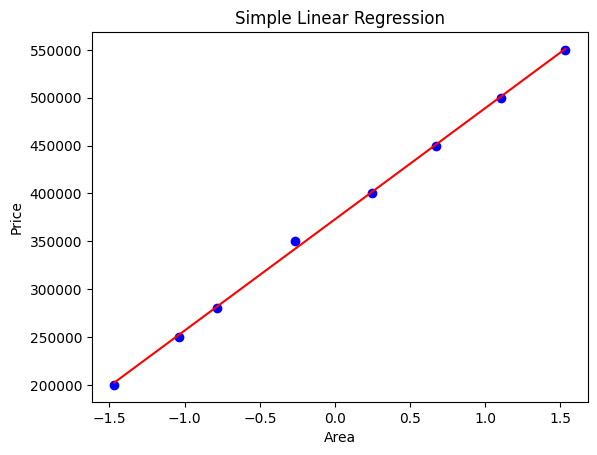

In [14]:
plt.scatter(X_simple, y, color='blue')
plt.plot(X_simple, model_simple.predict(X_simple), color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()


Multiple linear Regression


In [15]:
X_multi = df[['Area', 'Bedrooms', 'Age']]
y = df['Price']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)


In [17]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)


LinearRegression()

In [18]:
y_pred_multi = model_multi.predict(X_test)


In [19]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
print("MSE:", mse_multi)


MSE: 7984618.13522542


In [20]:
rmse_multi = np.sqrt(mse_multi)
print("RMSE:", rmse_multi)


RMSE: 2825.7066612133362


In [21]:
r2_multi = r2_score(y_test, y_pred_multi)
print("R2 Score:", r2_multi)


R2 Score: 0.9992015381864775


In [22]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_multi
})

print(comparison)


   Actual      Predicted
1  250000  253518.866169
5  450000  451893.889424
